# 🏥 Hospital Readmission Prediction (UCI Diabetes Dataset)

This project builds an interpretable machine learning model to predict hospital readmissions using the UCI Diabetes 130-US hospitals dataset. It applies real-world techniques for class imbalance, model evaluation, and interpretability using SHAP.

## 1. Introduction

Hospital readmissions are a major concern in healthcare due to their cost and potential to reflect preventable issues in care delivery. In this project, we aim to build a machine learning model that can predict whether a diabetic patient will be readmitted to the hospital using the UCI Diabetes dataset.

We will:
- Clean and prepare over 100K patient records
- Handle significant class imbalance in the target variable
- Train an XGBoost model for classification
- Evaluate performance using recall and precision-recall curves
- Use SHAP for model interpretability

This notebook walks through the end-to-end workflow from data preparation to model explanation.

## 2. Data Loading & Initial Exploration

We load the UCI Diabetes dataset containing 100K+ records across 130 hospitals. First, we inspect its shape, basic statistics, and class distribution for the `readmitted` column.

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score
from xgboost import XGBClassifier, plot_importance
import shap
from pathlib import Path

# Load the data
data_path = Path("..") / "data" / "diabetic_data.csv"
df = pd.read_csv(data_path)

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


2. ## EDA

In [34]:
# Preview shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (101766, 49)

Missing values:
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipton              

In [2]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


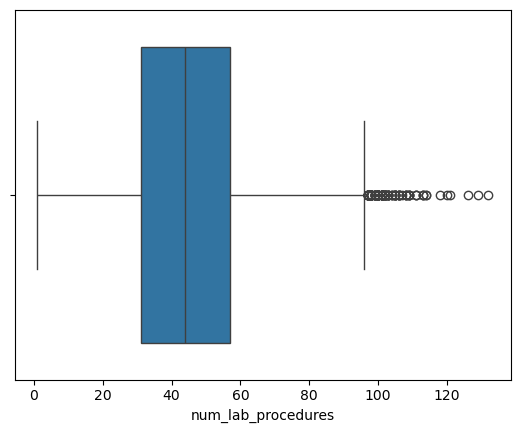

In [33]:
sns.boxplot(x=df['num_lab_procedures'])
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

## 3. Data Cleaning

We clean the dataset to ensure it is ready for machine learning:

- Drop or encode ID fields
- Replace placeholder missing values (`'?'`) with `NaN`
- Encode or drop low-utility columns
- Check and handle missing values
- Prepare categorical columns for encoding

In [4]:
df.drop(['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)


In [6]:
# Check for placeholder '?' values
(df == '?').sum().sort_values(ascending=False)

race                        2273
diag_3                      1423
diag_2                       358
diag_1                        21
gender                         0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
age                            0
admission_type_id              0
discharge_disposition_id       0
number_inpatient               0
number_emergency               0
number_outpatient              0
number_diagnoses               0
max_glu_serum                  0
A1Cresult                      0
metformin                      0
repaglinide                    0
nateglinide                    0
chlorpropamide                 0
glimepiride                    0
acetohexamide                  0
glipizide                      0
glyburide                      0
tolbutamide                    0
pioglitazone                   0
rosiglitazone                  0
acarbose  

In [7]:
df.replace('?', np.nan, inplace=True)

In [9]:
# Impute 'race' with the most frequent category
df['race'] = df['race'].fillna(df['race'].mode()[0])

# Impute diag_1/2/3 with 'Unknown'
df[['diag_1', 'diag_2', 'diag_3']] = df[['diag_1', 'diag_2', 'diag_3']].fillna('Unknown')

In [10]:
# Actual missing values (NaNs)
df.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
age                             0
gender                          0
race                            0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
admission_type_id               0
discharge_disposition_id        0
number_inpatient                0
number_emergency                0
diag_1                          0
diag_2                          0
number_diagnoses                0
diag_3                          0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone 

In [11]:
df.drop(['max_glu_serum', 'A1Cresult'], axis=1, inplace=True)

In [12]:
# Raw counts
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [13]:
df.gender.value_counts()


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [18]:
# 1. One-hot encode 'gender' and assign to X
df = pd.get_dummies(df, columns=['gender'])

# 2. Ensure all expected dummy columns exist (safe even if a value is missing)
for col in ['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']:
    if col not in df.columns:
        df[col] = 0

# 3. Cast the dummy columns to int
df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']] = df[['gender_Female', 'gender_Male', 'gender_Unknown/Invalid']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   age                       101766 non-null  object
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  diag_1                    101766 non-null  object
 12  diag_2                    101766 non-null  object
 13  diag_3                    101766 non-null  object
 14  numb

In [14]:
df.race.value_counts()

race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [16]:
df = pd.get_dummies(df, columns=['race'], prefix='race')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   age                       101766 non-null  object
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  diag_1                    101766 non-null  object
 12  diag_2                    101766 non-null  object
 13  diag_3                    101766 non-null  object
 14  numb

In [20]:
df.age.value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [21]:
age_map = {
    '[0-10)'   : 0,
    '[10-20)'  : 1,
    '[20-30)'  : 2,
    '[30-40)'  : 3,
    '[40-50)'  : 4,
    '[50-60)'  : 5,
    '[60-70)'  : 6,
    '[70-80)'  : 7,
    '[80-90)'  : 8,
    '[90-100)' : 9
}

df['age'] = df['age'].map(age_map)

In [22]:
df.age.value_counts()

age
7    26068
6    22483
5    17256
8    17197
4     9685
3     3775
9     2793
2     1657
1      691
0      161
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   age                       101766 non-null  int64 
 1   admission_type_id         101766 non-null  int64 
 2   discharge_disposition_id  101766 non-null  int64 
 3   admission_source_id       101766 non-null  int64 
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  diag_1                    101766 non-null  object
 12  diag_2                    101766 non-null  object
 13  diag_3                    101766 non-null  object
 14  numb

In [24]:
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in drug_columns:
    df[col] = df[col].apply(lambda x: 0 if x == 'No' else 1)

In [25]:
df['change'] = df['change'].apply(lambda x: 1 if x == 'Ch' else 0)
df['diabetesMed'] = df['diabetesMed'].apply(lambda x: 1 if x == 'Yes' else 0)

In [29]:
def map_diagnosis(code):
    try:
        code = float(code)
    except:
        return 0  # unknown

    if 390 <= code <= 459 or code == 785:
        return 1  # Circulatory
    elif 460 <= code <= 519 or code == 786:
        return 2  # Respiratory
    elif 520 <= code <= 579 or code == 787:
        return 3  # Digestive
    elif 250 <= code < 251:
        return 4  # Diabetes
    elif 800 <= code <= 999:
        return 5  # Injury
    elif 710 <= code <= 739:
        return 6  # Musculoskeletal
    elif 580 <= code <= 629 or code == 788:
        return 7  # Genitourinary
    elif 140 <= code <= 239:
        return 8  # Neoplasms
    else:
        return 0  # Other

In [30]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].apply(map_diagnosis).astype(int)

In [27]:
# Convert 'readmitted' to binary: 1 if <30 days, 0 otherwise
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df.drop(columns=['readmitted'], inplace=True)
# Show updated class distribution
df['readmitted_binary'].value_counts()


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   age                       101766 non-null  int64
 1   admission_type_id         101766 non-null  int64
 2   discharge_disposition_id  101766 non-null  int64
 3   admission_source_id       101766 non-null  int64
 4   time_in_hospital          101766 non-null  int64
 5   num_lab_procedures        101766 non-null  int64
 6   num_procedures            101766 non-null  int64
 7   num_medications           101766 non-null  int64
 8   number_outpatient         101766 non-null  int64
 9   number_emergency          101766 non-null  int64
 10  number_inpatient          101766 non-null  int64
 11  diag_1                    101766 non-null  int64
 12  diag_2                    101766 non-null  int64
 13  diag_3                    101766 non-null  int64
 14  number_diagnoses    

🛠️ Feature Engineering Summary

    Replaced placeholder values ('?') with NaN and handled missing data appropriately.

    Imputed missing categorical values (race, diag_1/2/3) using mode or custom logic.

    Grouped ICD-9 diagnosis codes into broad disease categories.

    Encoded categorical variables using one-hot or ordinal encoding:

        max_glu_serum and A1Cresult encoded as ordinal (severity-based) integers.

    Ensured all features are numeric (int, float, bool) for model compatibility.

    Final dataset shape: (101765, 49)

    Ready for model training.

In [32]:
# If you have the full DataFrame (e.g., df), do this:
y = df['readmitted_binary']
X = df.drop(columns=['readmitted_binary'])

In [ ]:
print(y.unique())  # Should show: [0 1 2]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional: Drop NaNs just in case
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

## 5. Modeling with XGBoost

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

In [ ]:
print(model)  

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
print(y_test.value_counts(normalize=True))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))

In [ ]:
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

## 6. Evaluation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print(feature_importance.head(15))


In [ ]:
# ratio of negative / positive examples
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss')
model.fit(X_train, y_train)


In [ ]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test), target_names=["Not Readmitted", "Readmitted"]))


## 7. Model Interpretability with SHAP

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=15, importance_type='gain')  # or 'weight' or 'cover'
plt.title("Top 15 Feature Importances (by Gain)")
plt.show()


In [ ]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=15)


## 8. Conclusion

Final remarks and potential future work directions.